# Duc Hai Ho - 11252779 - AI67B

### **ATTENTION**
During the working process, I noticed that the country data (raw extract from the original data [countries.csv]("./countries.csv")) can contain multiple countries at once, separated by "," (e.g: "United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia"). Therefore, I have also implemented my own data cleaning & extraction besides from the provided guide.

Also, in the choropleth graph (distribution of films by countries), I've also noticed that the difference between the count of the US and the rest of the world is dramatic, so I implemented `log10(count)` for the graph to have smoother transition

### Files:
- `netflix_titles.csv`: original data
- `netflix_cleaned.csv`: cleaned data implemented by the provided guide's method
- `countries`: countries extraction from original data
- `separated_countries`: separated countries implemented by my own method

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

data = pd.read_csv("./netflix_titles.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


## Cleaning data

In [2]:

data.fillna({"director": "Unknown"}, inplace=True)
data.fillna({"cast": "Unknown"}, inplace=True)
data.fillna({"country": "Unknown"}, inplace=True)

# Drop rows with missing "date_added" or "rating"
data.dropna(subset=["date_added", "rating"], inplace=True)

# Convert "date_added" to datetime
data['date_added'] = pd.to_datetime(data['date_added'].str.strip())
data['year_added'] = data['date_added'].dt.year
data['month_added'] = data['date_added'].dt.month

data.to_csv("netflix_cleaned.csv", index=False)

data.info()

<class 'pandas.DataFrame'>
Index: 8793 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8793 non-null   str           
 1   type          8793 non-null   str           
 2   title         8793 non-null   str           
 3   director      8793 non-null   str           
 4   cast          8793 non-null   str           
 5   country       8793 non-null   str           
 6   date_added    8793 non-null   datetime64[us]
 7   release_year  8793 non-null   int64         
 8   rating        8793 non-null   str           
 9   duration      8790 non-null   str           
 10  listed_in     8793 non-null   str           
 11  description   8793 non-null   str           
 12  year_added    8793 non-null   int32         
 13  month_added   8793 non-null   int32         
dtypes: datetime64[us](1), int32(2), int64(1), str(10)
memory usage: 961.7 KB


### Clean the country data

In [3]:
separated_countries = data["country"].str.split(",").explode().str.strip()
separated_countries.to_csv("separated_countries.csv", index=False)

## Matplotlib basic visualization

### Bar Chart: Content Type Distribution

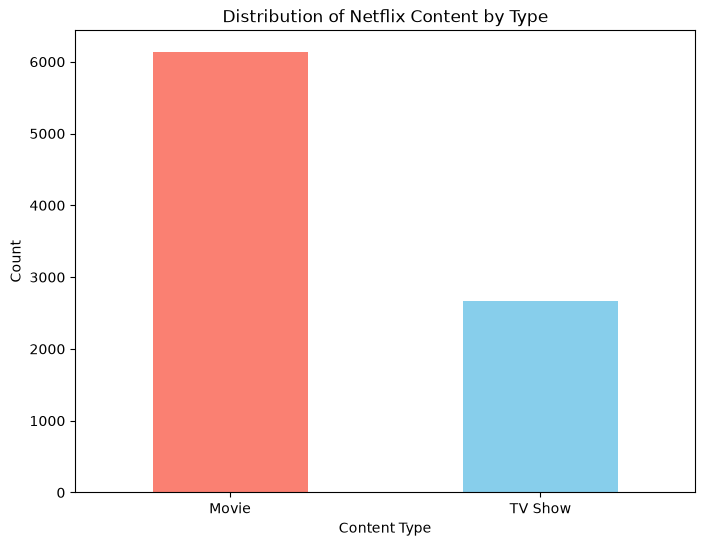

In [4]:
plt.figure(figsize=(8, 6))
data['type'].value_counts().plot(kind="bar", color=["salmon", "skyblue"])
plt.title("Distribution of Netflix Content by Type")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### Line Plot: Content Added Over Time

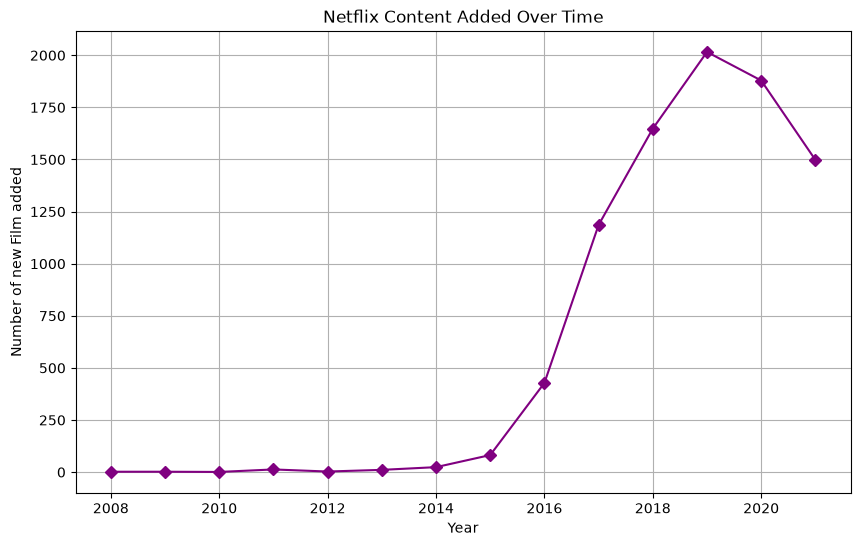

In [5]:
yearly_content = data["year_added"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
plt.plot(yearly_content.index, yearly_content.values, marker="D", color = "purple")
plt.title("Netflix Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of new Film added")
plt.grid(True)
plt.show()

### My own extension

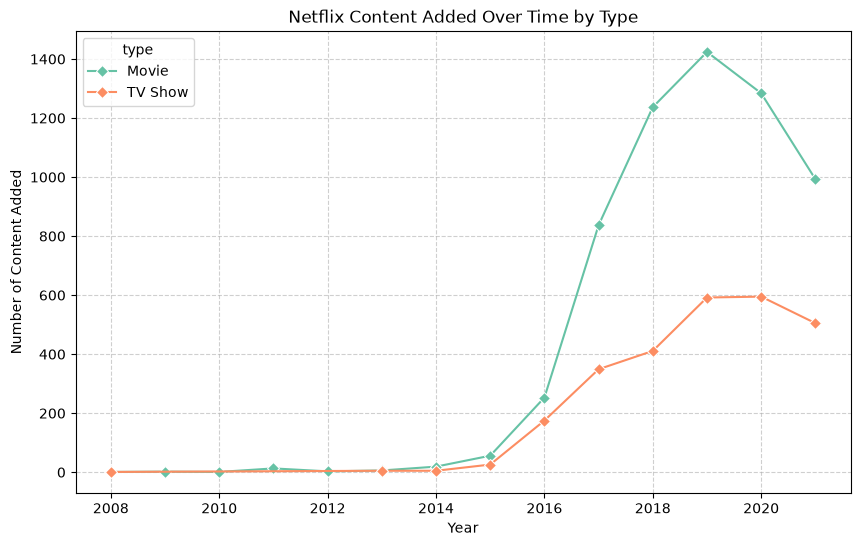

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

content_by_year_type = (
    data.groupby(["year_added", "type"]).size().reset_index(name="count")
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=content_by_year_type,
    x="year_added",
    y="count",
    hue="type",
    marker="D",
    palette="Set2",
)

plt.title("Netflix Content Added Over Time by Type")
plt.xlabel("Year")
plt.ylabel("Number of Content Added")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Seaborn Statistical Visualization

### Top 10 Countries Producting Content

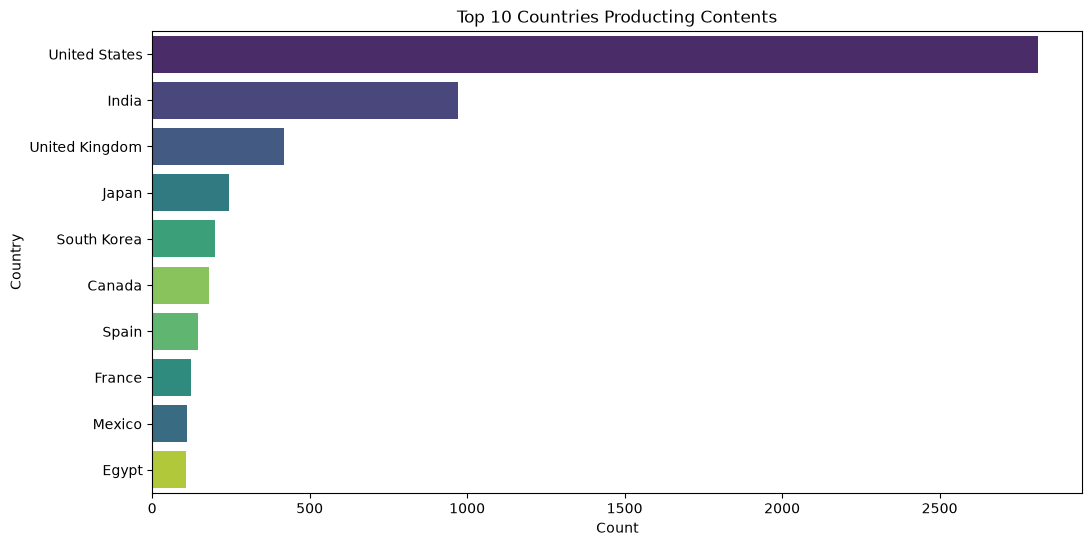

In [38]:
top_countries = data[data['country'] != "Unknown"]["country"].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.countplot(
    y="country", 
    hue="country",
    data=data[data['country'].isin(top_countries.index)], 
    order=top_countries.index, 
    palette='viridis'
)
plt.title("Top 10 Countries Producting Contents")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

#### Fixing

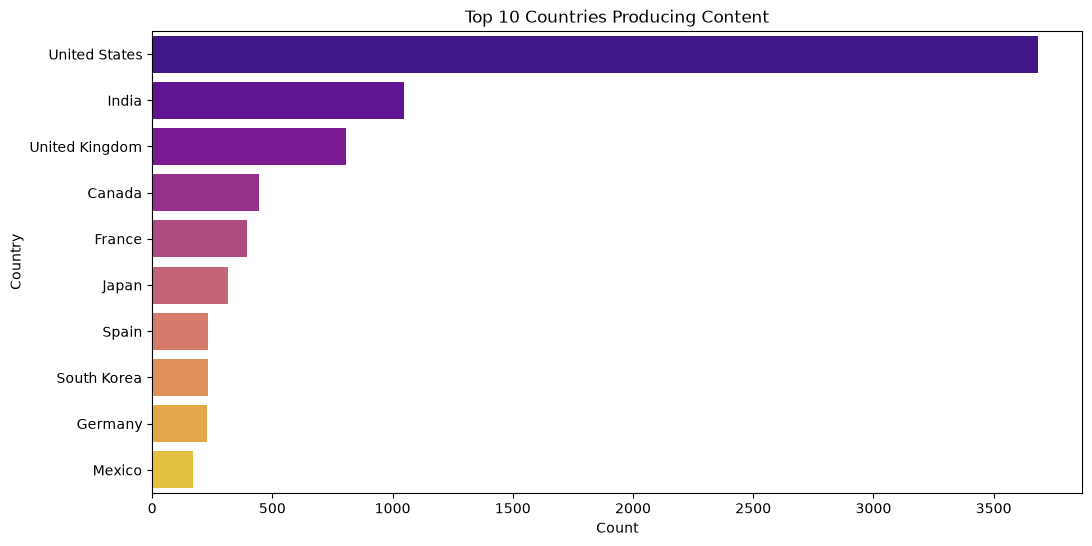

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

top_countries = (
    data[data["country"] != "Unknown"]["country"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    y=top_countries.index,
    hue=top_countries.index, 
    x=top_countries.values,
    palette="plasma",
    legend=False
)

plt.title("Top 10 Countries Producing Content")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

### BoxPlot: Release Year by Content Type

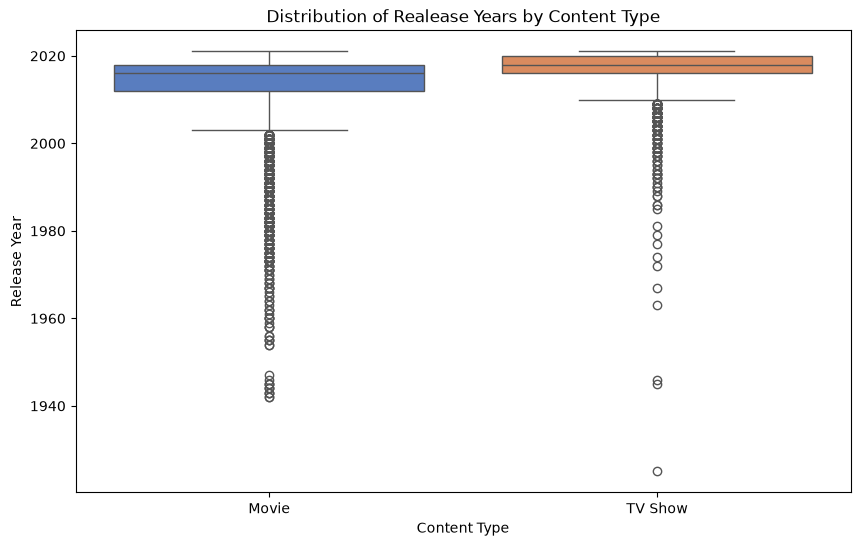

In [32]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="type", y="release_year", data=data, palette="muted", hue="type", legend=False)
plt.title("Distribution of Realease Years by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Release Year")
plt.show()

### Heatmap: Content added by Month and Year

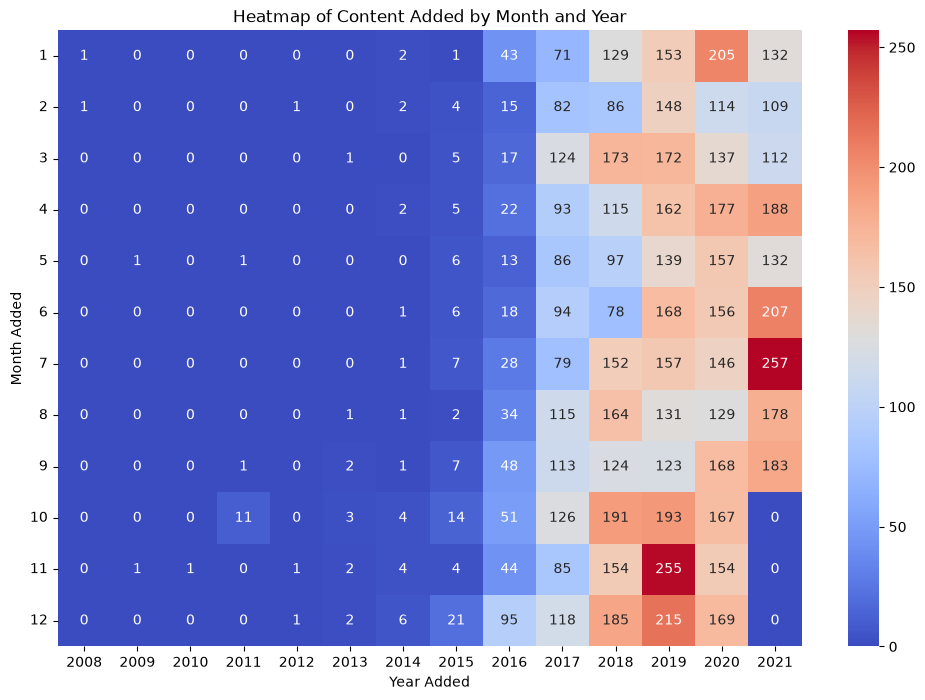

In [9]:
heatmap_data = data.pivot_table(
    index="month_added",
    columns="year_added",
    values="show_id",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap="coolwarm", annot=True, fmt="d")
plt.title("Heatmap of Content Added by Month and Year")
plt.xlabel("Year Added")
plt.ylabel("Month Added")
plt.yticks(rotation=0)
plt.show()

### Season added

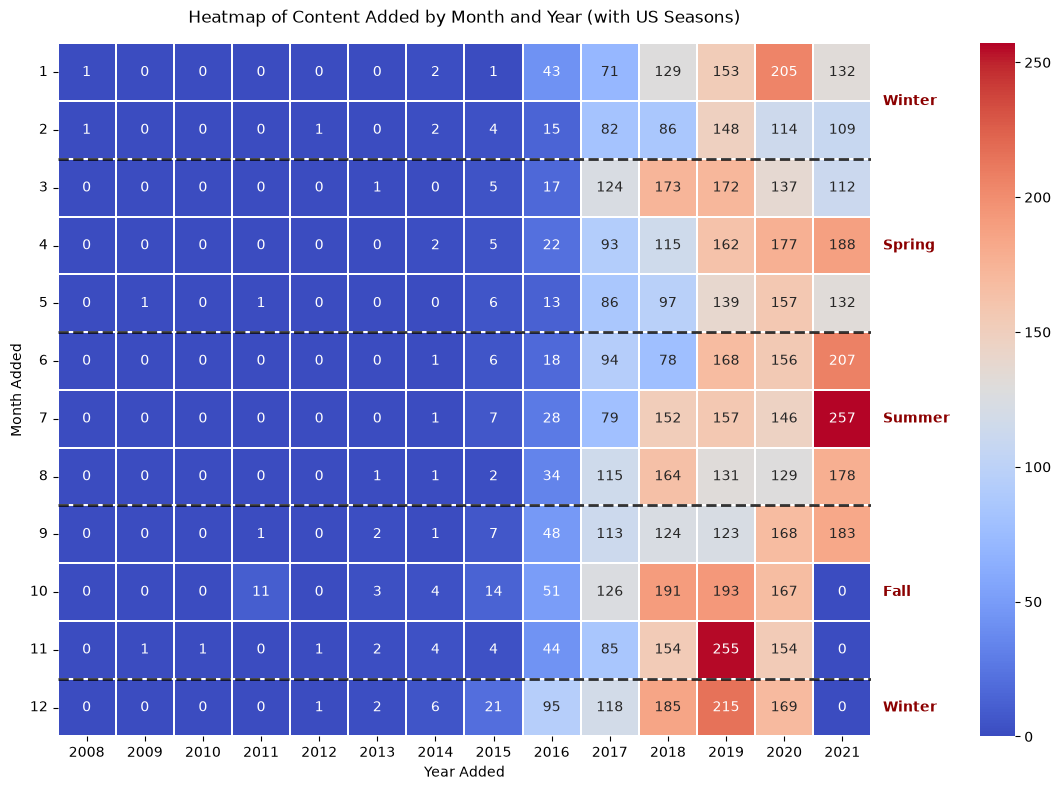

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

heatmap_data = (
    data.pivot_table(
        index="month_added",
        columns="year_added",
        values="show_id",
        aggfunc="count",
        fill_value=0,
    )
    .dropna(how="all")
)

plt.figure(figsize=(14, 9))
ax = sns.heatmap(
    heatmap_data, cmap="coolwarm", annot=True, fmt="d", linewidths=0.2, cbar_kws={"pad": 0.10},
)

season_cutoffs = [2, 5, 8, 11]
for y in season_cutoffs:
    plt.axhline(y, color="black", linestyle="--", linewidth=2, alpha=0.8)

season_labels = [
    (1, "Winter"),
    (3.5, "Spring"),
    (6.5, "Summer"),
    (9.5, "Fall"),
    (11.5, "Winter"),
]

for y_pos, label in season_labels:
    ax.text(
        ax.get_xlim()[1] + 0.2,
        y_pos,
        label,
        va="center",
        ha="left",
        fontweight="bold",
        color="darkred",
    )

plt.title(
    "Heatmap of Content Added by Month and Year (with US Seasons)", pad=15
)
plt.xlabel("Year Added")
plt.ylabel("Month Added")
plt.yticks(rotation=0)
plt.show()

## Plotly Interactive Visualization

### Pie Chart: Content Type Breakdown

In [10]:
fig = px.pie(
    data,
    names="type",
    title="Netflix Content Type Breakdown",
    color_discrete_sequence=["#FF6F61", "#6B5B95"]
)
fig.show()

### Scatter Plot: Release Year and Year Added

In [11]:
fig = px.scatter(
    data_frame=data,
    x="release_year",
    y="year_added",
    color="type",
    title="Release Year bs Year Added by Content Type",
    labels={
        "release_year": "Release Year",
        "year_added": "Year Added"
    },
)

fig.show()

#### Heatmap addition

In [60]:
fig = px.density_heatmap(
    data_frame=data,
    x="release_year",
    y="year_added",
    facet_col="type",
    nbinsx=30,
    nbinsy=20,
    color_continuous_scale=px.colors.sequential.Agsunset,
    marginal_x="histogram",
    marginal_y="histogram",
    title="Heatmap of Content Density: Release Year vs Year Added",
    labels={"release_year": "Release Year", "year_added": "Year Added"},
)

fig.show()

### Choropleth Graph: Content by Country

In [12]:
country_counts = data[data['country'] != 'Unknown']["country"].value_counts().reset_index()
country_counts.columns = ['country', 'count']

fig=px.choropleth(
    data_frame=country_counts,
    locations='country',
    locationmode='country names',
    color='count',
    title="Netflix Content Distribution by Country",
    width= 1200,
    height=800,
    color_continuous_scale=px.colors.sequential.Oranges,
)

fig.update_layout(
    margin=dict(l=0, r=0, t=50, b=0),  # Giảm lề trắng để bản đồ chiếm trọn khung
    geo=dict(
        showframe=True,
        showcoastlines=True,
        projection_type='natural earth'
    )
)

fig.show()

![alt text](https://github.com/Hai567/public_assets/blob/main/newplot.png?raw=true)

#### Fixing

In [13]:
country_counts = data[data['country'] != 'Unknown']["country"].str.split(',').explode().str.strip().value_counts().reset_index()
country_counts.columns = ['country', 'count']
country_counts['log10count'] = np.log10(country_counts['count'])

fig=px.choropleth(
    data_frame=country_counts,
    locations='country',
    locationmode='country names',
    color='log10count',
    title="Netflix Content Distribution by Country",
    width= 1200,
    height=800,
    color_continuous_scale=px.colors.sequential.Oranges,
    hover_data={
        "country": True,
        "log10count": False,
        "count": ":.d"
    }
)

fig.update_layout(
    margin=dict(l=0, r=0, t=50, b=0),  # Giảm lề trắng để bản đồ chiếm trọn khung
    geo=dict(
        showframe=True,
        showcoastlines=True,
        projection_type='natural earth'
    )
)

fig.show()

![alt text](https://github.com/Hai567/public_assets/blob/main/newplot1.png?raw=true)

In [14]:
data['country'].to_csv("countries.csv", index=False)

In [15]:
country_counts

,country,count,log10count
0,United States,3684,3.566320
1,India,1046,3.019532
2,United Kingdom,805,2.905796
3,Canada,445,2.648360
4,France,393,2.594393
...,...,...,...
118,Sudan,1,0.000000
119,Panama,1,0.000000
120,Uganda,1,0.000000
121,East Germany,1,0.000000


## Part 5: Interpretation & Insights

1. The diistribution of _Movies_ and _TV Shows_ suggest that Netflix puts more attention on distribtuting _Movies_ than _TV Show_ (more than twice)
2. From 2008 to 2014, the number of content added increase marginally. However, from 2014 forwards, the addition surged dramatically and peaked at 2000 in 2019. Then, there has been a steep decline trend over the next 2 years, dropped to 1500 in 2021.
Looking at the heatmap, there is no correlation between seasons and the number of content added
3. In the Choropleth graph, it's obvious that the US dominates the content production, about 3.5 times more than India (in the second place). This can imply that the US content has higher priority than the rest of the other countries
4. Looking at the scatterplot, the addition of content new to Netflix ranging from very old to modern films. However, zooming in to the heatmap directly below, it is obvious that new contents are more likely to be added than older contents

## Part 7: Optional Extentsions

### Genre analysis

In [61]:
data.info()

<class 'pandas.DataFrame'>
Index: 8793 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8793 non-null   str           
 1   type          8793 non-null   str           
 2   title         8793 non-null   str           
 3   director      8793 non-null   str           
 4   cast          8793 non-null   str           
 5   country       8793 non-null   str           
 6   date_added    8793 non-null   datetime64[us]
 7   release_year  8793 non-null   int64         
 8   rating        8793 non-null   str           
 9   duration      8790 non-null   str           
 10  listed_in     8793 non-null   str           
 11  description   8793 non-null   str           
 12  year_added    8793 non-null   int32         
 13  month_added   8793 non-null   int32         
dtypes: datetime64[us](1), int32(2), int64(1), str(10)
memory usage: 961.7 KB


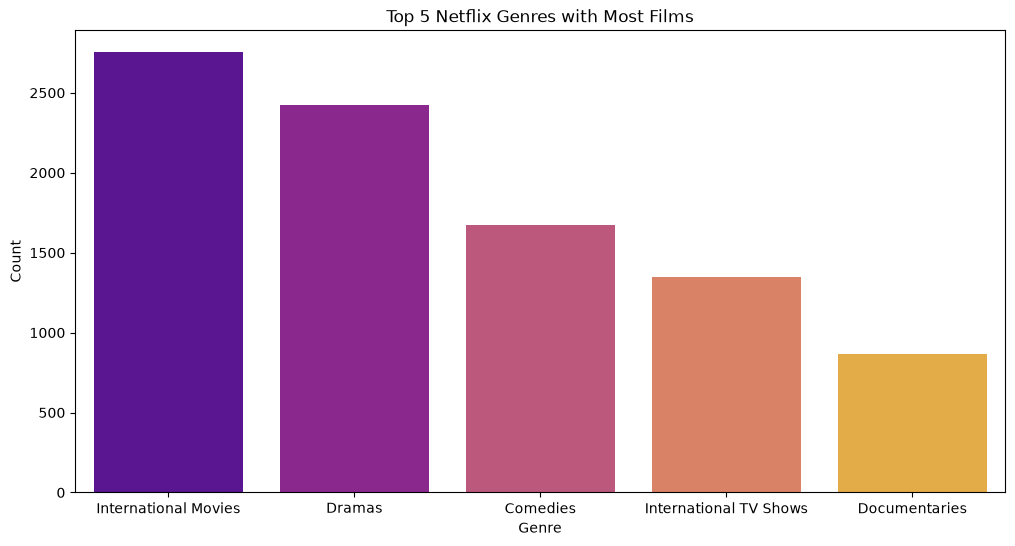

In [71]:
top5_genere = data['listed_in'].str.split(",").explode().str.strip().value_counts().head()

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top5_genere.index, 
    y=top5_genere.values,
    hue=top5_genere.index,
    palette="plasma",
    legend=False
)

plt.title("Top 5 Netflix Genres with Most Films")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

### Rating distribution

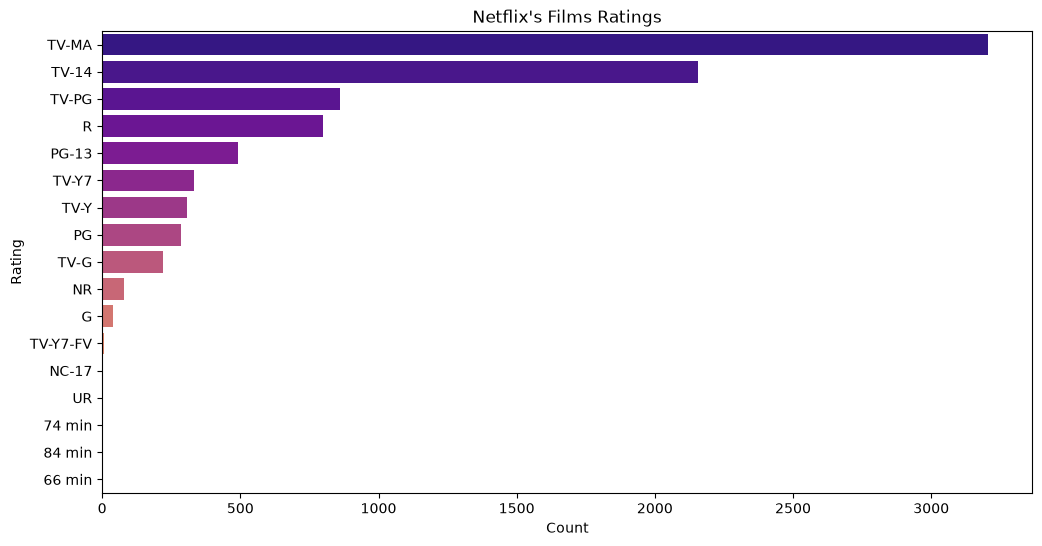

In [79]:
ratings = data['rating'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(
    y=ratings.index,
    hue=ratings.index,
    x=ratings.values,
    palette="plasma",
    legend=False,
    
)

plt.title("Netflix's Films Ratings")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.show()

### Duration Analysis

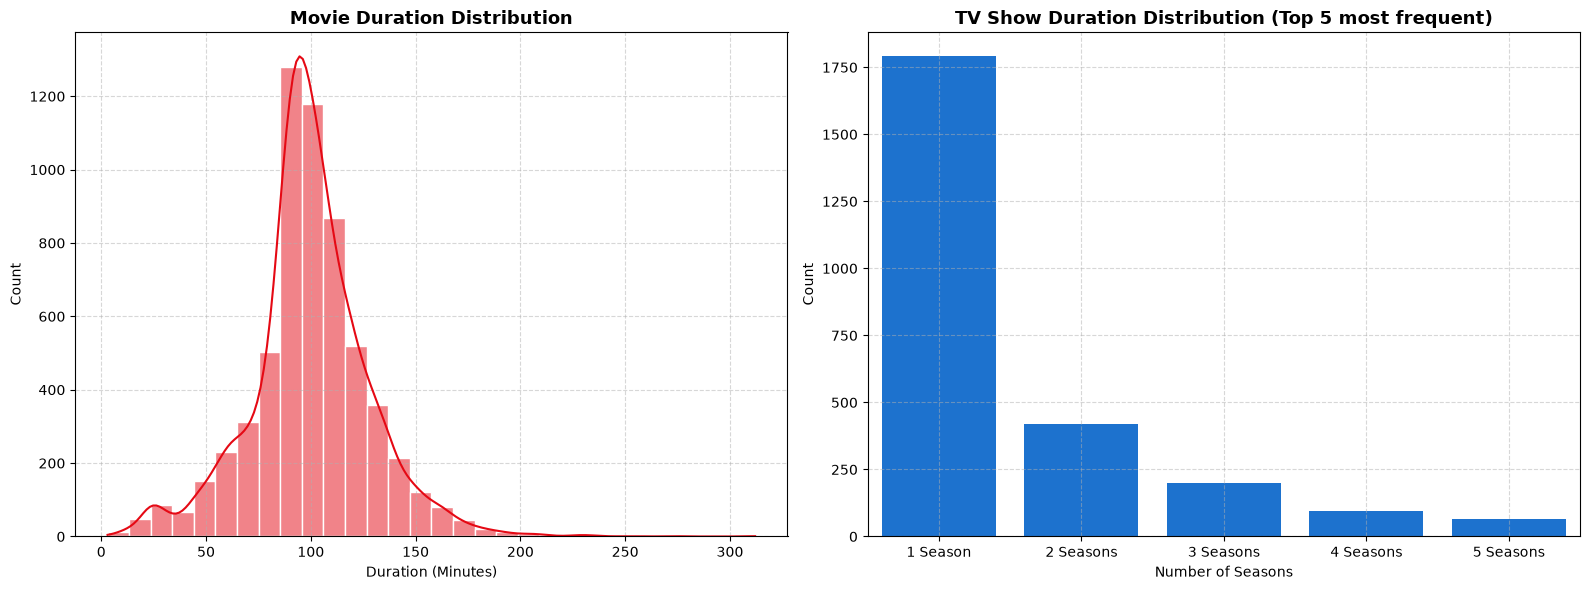

In [121]:
tv = data[data["type"] == "TV Show"]
movies = data[data["type"] == "Movie"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

movies["duration_num"] = (movies['duration'].str.split(" min").str[0].dropna().astype(int))

# Movie plot
sns.histplot(
    movies["duration_num"],
    bins=30,
    kde=True,
    color="#E50914",
    ax=axes[0],
    edgecolor="white",
)
axes[0].set_title("Movie Duration Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Duration (Minutes)")
axes[0].set_ylabel("Count")
axes[0].grid(True, linestyle="--", alpha=0.5)

# TV Show plot
sns.countplot(
    data=tv,
    x="duration",
    color="#0071EB",
    ax=axes[1],
    order=tv["duration"].value_counts().index[:5],
)
axes[1].set_title(
    "TV Show Duration Distribution (Top 5 most frequent)",
    fontsize=13,
    fontweight="bold",
)
axes[1].set_xlabel("Number of Seasons")
axes[1].set_ylabel("Count")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [114]:
movies['duration'].str.split(" min").str[0].isna().value_counts()

duration
False    6126
True        3
Name: count, dtype: int64